# STEP 1: FORMULATE QUESTION

# RESEARCH QUESTION

How do distance and preparation time affect food delivery time?

# OBJECTIVES

1. To analyze the relationship between distance, preparation time, and delivery time.

2. To build a multiple linear regression model using distance and preparation time as predictors.

3. To evaluate how accurately the model predicts food delivery time.

# VARIABLES

Independent Variables (X):
   
        Distance in kilometers
        Preparation time in minutes 

Dependent Variable (y):
    
         Delivery time in minutes


# STEP 2: DATA CLEANING and EDA

Step 2.1: Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

## Explanation

This step imports the needed Python libraries for data handling, visualization, model training, and model evaluation. The dataset is loaded using pandas. The `head()` function displays the first five rows of the dataset to check if the file was loaded correctly.

In [3]:
df = pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [4]:
df. head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [5]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df. describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [7]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
df = df[["Distance_km", "Preparation_Time_min", "Delivery_Time_min"]]

df.columns = ["Distance", "Preparation_Time", "Delivery_Time"]

df.head()

,Distance,Preparation_Time,Delivery_Time
0,7.93,12,43
1,16.42,20,84
2,9.52,28,59
3,7.44,5,37
4,19.03,16,68


# Step 2.7: Explanatory Data Analysis(EDA)

A. Scatter Plot

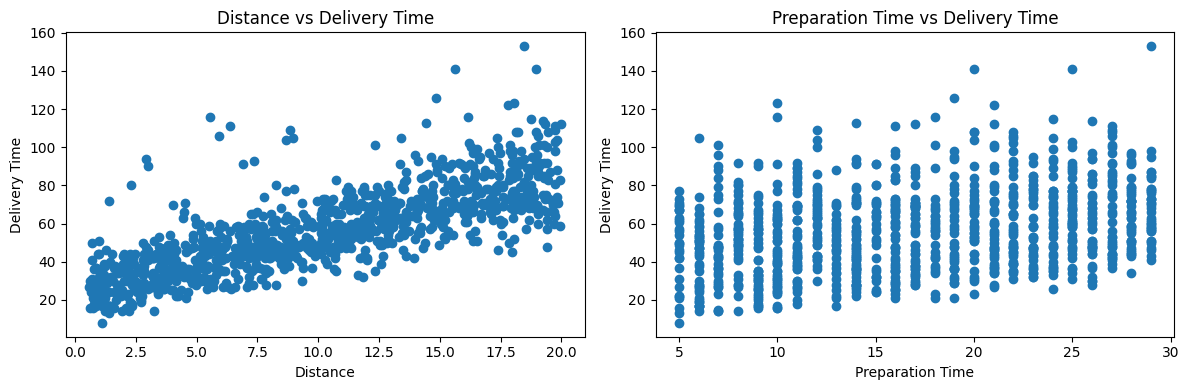

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.scatter(df["Distance"], df["Delivery_Time"])
plt.xlabel("Distance")
plt.ylabel("Delivery Time")
plt.title("Distance vs Delivery Time")

plt.subplot(1,2,2)
plt.scatter(df["Preparation_Time"], df["Delivery_Time"])
plt.xlabel("Preparation Time")
plt.ylabel("Delivery Time")
plt.title("Preparation Time vs Delivery Time")

plt.tight_layout()
plt.show()

Purpose: this cell creates two side-by-side scatter plots to visually check how each selected variable relates to Delivery Time.

What each part does:

- plt.figure(figsize=(10,4)): sets one wide figure canvas.
- plt.subplot(1,2,1), ...2: splits the figure into 1 row and 2 columns.
- plt.scatter(df["Distance"], df["Delivery_Time"]): plots Distance vs Delivery Time.
- plt.scatter(df["Preparation_Time"], df["Delivery_Time"]): plots Preparation Time vs Delivery Time.
- plt.xlabel(...), plt.ylabel("Delivery Time"): labels the x-axis and y-axis.
- plt.title(...): adds a title to each graph.
- plt.tight_layout(): prevents overlap between the graphs.
- plt.show(): displays the plots.

Why this is important:

- Helps compare which variable has a stronger relationship with Delivery Time.
- A clearer upward pattern means the variable may be a good predictor.
- This is an important EDA step before training the multiple linear regression model.

B. CORRELATION MATRIX

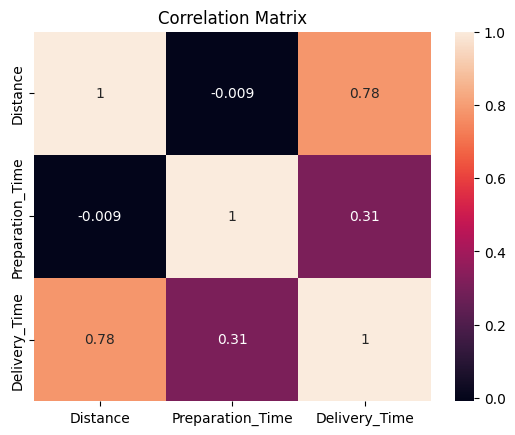

In [14]:
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Purpose: this cell creates a correlation matrix to check the relationship between Distance, Preparation Time, and Delivery Time.

What each part does:

- df.corr(): calculates the correlation values between the numeric columns.
- sns.heatmap(...): displays the correlation values as a heatmap.
- annot=True: shows the correlation numbers inside the heatmap.
- plt.title("Correlation Matrix"): adds a title to the chart.
- plt.show(): displays the heatmap.

Why this is important:

- It helps identify which independent variable has a stronger relationship with Delivery Time.
- A value closer to 1 means a stronger positive relationship.
- A value closer to 0 means a weaker relationship.
- This helps support the variable selection before training the multiple linear regression model.

C. Pairplot

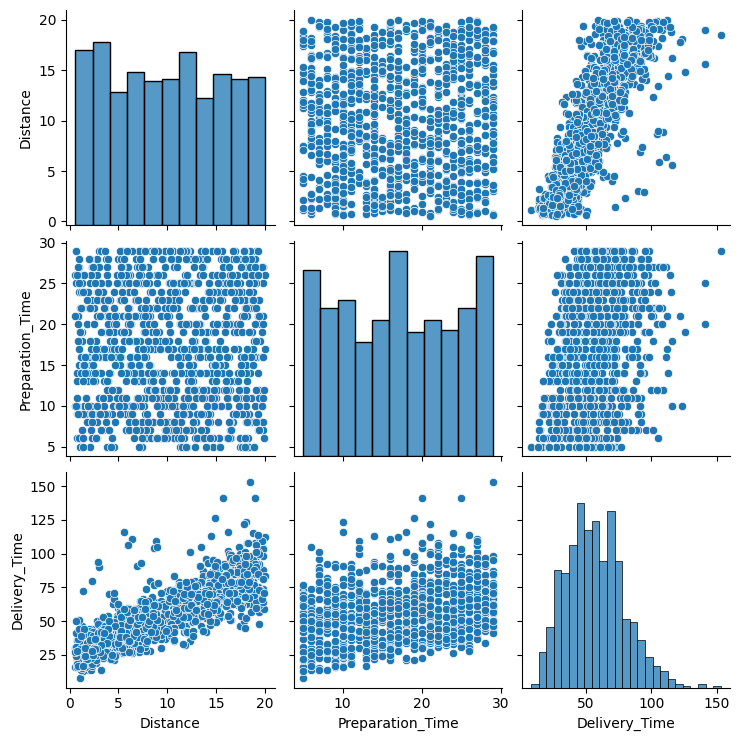

In [35]:
sns.pairplot(df)
plt.show()

Purpose: this cell creates a pairplot to show the relationship between all selected variables.

What each part does:

- sns.pairplot(df): creates scatter plots for each pair of variables and distribution plots for each variable.
- plt.show(): displays the pairplot.

Why this is important:

- It helps check the overall pattern between Distance, Preparation Time, and Delivery Time.
- It helps see if the variables have a possible linear relationship.
- It also helps detect possible outliers in the dataset.
- This is useful before training the multiple linear regression model.

# STEP 3: MODEL TRAINING

Step 3.1: Define x and y

In [20]:
X = df[["Distance", "Preparation_Time"]]
y = df["Delivery_Time"]

We will use Distance and Preparation_Time as input features and Delivery_Time as outcome feature.

Step 3.2

In [21]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

This code splits the data into training and testing sets. 
80% of the data will be used to train the model, while 20% will be used to test how well the model predicts delivery time. 
The random_state=42 makes the result consistent every time the code is run.

Step 3.3: Create Model

In [22]:
model =LinearRegression()

model = LinearRegression() creates the multiple linear regression model.

Purpose:

- chooses the regression algorithm for the prediction,
- prepares the model before training,
- does not train or learn from the data yet,
- the model will learn only after using model.fit(X_train, y_train).

Step 3.4: Train Model

In [23]:
model.fit(X_train, y_train)

LinearRegression()

The purpose of model.fit(X_train, y_train) is to train the multiple linear regression model.

It learns:

- the intercept or b0
- the coefficients or b1 and b2
- the relationship between Distance, Preparation_Time, and Delivery_Time

Step 3.5: View Coefficients

In [24]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

Intercept: 9.530656489425098


,Feature,Coefficient
0,Distance,3.037216
1,Preparation_Time,0.986056


#Coefficient Interpretation

#Multiple Linear Regression Formula

The formula for multiple linear regression is:

y_predicted = b0 + b1(x1) + b2(x2)

Where:

- y_predicted = predicted Delivery_Time
- b0 = intercept
- b1 = coefficient of Distance
- b2 = coefficient of Preparation_Time
- x1 = Distance
- x2 = Preparation_Time

#Model Equation

Based on the selected variables, the model equation is:

Delivery_Time = b0 + b1(Distance) + b2(Preparation_Time)

#Interpretation of Coefficients

#Intercept

The intercept is b0.

This means that when Distance and Preparation_Time are both zero, the predicted Delivery_Time starts at this value.

#Feature Coefficients

| Feature | Coefficient | Interpretation |
|---|---:|---|
| Distance | b1 | For every 1 unit increase in Distance, Delivery_Time changes by b1, while Preparation_Time stays the same. |
| Preparation_Time | b2 | For every 1 unit increase in Preparation_Time, Delivery_Time changes by b2, while Distance stays the same. |

#Key Insights

1. Strongest Predictor

The feature with the larger coefficient has the stronger effect on Delivery_Time.

2. Effect on Delivery_Time

If the coefficient is positive, the feature increases Delivery_Time.  
If the coefficient is negative, the feature decreases Delivery_Time.

3. Model Meaning

The model uses Distance and Preparation_Time to predict Delivery_Time.

Step 3.6: Make Predictions

In [25]:
y_pred = model.predict(X_test)

Step 3.7: Compare Results

In [27]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head()

,Actual,Predicted
0,32,41.404803
1,68,65.951345
2,39,35.605798
3,44,43.309936
4,85,85.179003


This step compares the actual Delivery_Time values with the predicted values from the model.

Actual shows the real delivery time from the dataset.  
Predicted shows the delivery time estimated by the model.


# STEP 4: PERFORMANCE EVALUATION

Step 4.1: COMPUTE METRICS

In [28]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("Root Mean Squared Error: ", rmse)
print("R²:", r2)

Mean Absolute Error:  7.680351163763087
Mean Squared Error:  120.43753932898672
Root Mean Squared Error:  10.974403825674846
R²: 0.7313023400053361


This step computes the performance metrics of the model.

MAE shows the average prediction error.  
MSE shows the squared error and gives more weight to large mistakes.  
RMSE shows the error in the same unit as Delivery_Time.  
R² shows how much of the Delivery_Time is explained by Distance and Preparation_Time.


Step 4.2: VISUALIZATION OF ACTUAL VS PREDICTED

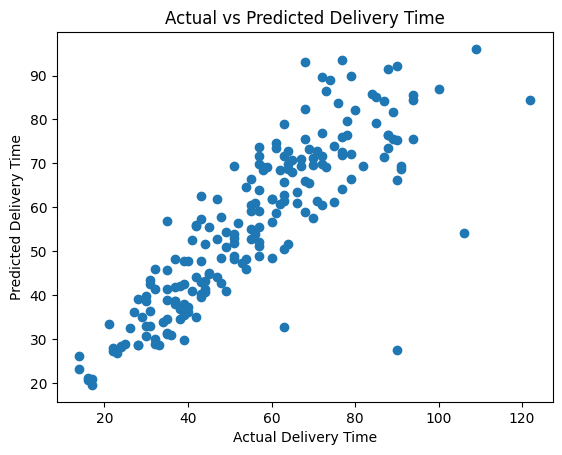

In [32]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")
plt.show()

This scatter plot compares the actual Delivery_Time values with the predicted values from the model.

If the points are close to each other in a clear upward pattern, the model predictions are better.  
If the points are widely scattered, the model has more prediction errors.

Step 4.3: Residuals

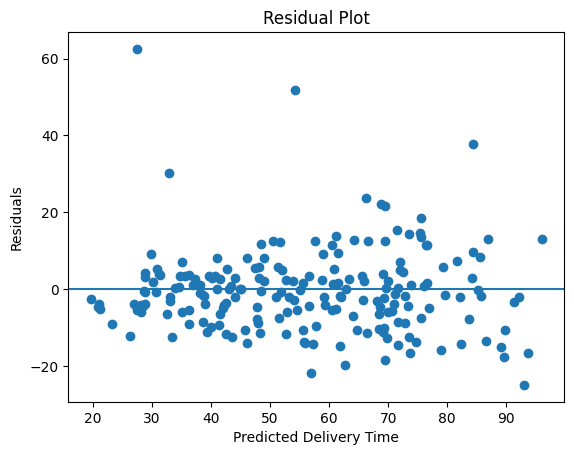

In [31]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Delivery Time")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#Interpretation

The residuals show the difference between the actual and predicted Delivery_Time. If the points are randomly scattered around the zero line, the model is acceptable. If the points form a clear pattern, the model may not be fitting the data well.

#Purpose

This residual plot checks the errors of the model by comparing the predicted Delivery_Time with the residuals.


Step 4.4: Predict New Data

In [33]:
new_data = pd.DataFrame({
    "Distance": [10],
    "Preparation_Time": [20]
})

prediction = model.predict(new_data)
print("Predicted Delivery Time:", prediction[0])

Predicted Delivery Time: 59.623944343125345


#Purpose

This step uses the trained model to predict Delivery_Time using new input values.

#Interpretation

With Distance = 10 and Preparation_Time = 20, the model predicts the Delivery_Time based on the learned pattern from the dataset.

This is only an estimate from the model, not an exact guaranteed delivery time.

Step 4.5: Export Trained Model

After training the multiple linear regression model, the model is saved as a `.pkl` file using `pickle`.

# REFLECTION AND ANALYSIS

## 1. Do the selected variables significantly affect delivery time?

Yes. Distance and Preparation_Time affect Delivery_Time. Based on the model, both variables have positive coefficients, meaning delivery time increases when distance or preparation time increases.

## 2. Identify limitations of the model and dataset

The model only uses Distance and Preparation_Time. Other factors like weather, traffic, time of day, vehicle type, and courier experience are not included, so the model may not predict all delivery situations perfectly.

## 3. Which variable contributes the most to delivery time? Justify using EDA and coefficients

Distance contributes the most to Delivery_Time. In the coefficient table, Distance has a coefficient of about 3.04, while Preparation_Time has about 0.99. This means Distance has a stronger effect on the prediction.

## 4. If the strongest predictor is removed, what will happen to model performance?

If Distance is removed, the model performance will likely become weaker. The prediction errors may increase and the R² value may decrease because Distance is the strongest predictor in the model.

## 5. Does correlation imply causation in this dataset?

No. Correlation does not always mean causation. For example, Distance and Delivery_Time are related, but other factors like traffic and weather can also affect delivery time.
```


In [37]:
%pip install pandas scikit-learn

import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

if "model" not in globals():
    if "df" not in globals():
        df = pd.read_csv("Food_Delivery_Times.csv")
        df = df[["Distance_km", "Preparation_Time_min", "Delivery_Time_min"]]
        df.columns = ["Distance", "Preparation_Time", "Delivery_Time"]

    X = df[["Distance", "Preparation_Time"]]
    y = df["Delivery_Time"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

export_path = "food_delivery_model.pkl"

with open(export_path, "wb") as f:
    pickle.dump(model, f)

print(f"Trained model exported to {export_path}")

You should consider upgrading via the '/Users/stephaniedoctor/Desktop/Food-Delivery-Time/.venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Trained model exported to food_delivery_model.pkl
